In [1]:
import mynn
from draw_tools.plot import plot
import numpy as np
from struct import unpack
import pickle
import gzip
import matplotlib.pyplot as plt

# fixed seed for experiment
np.random.seed(309)

train_images_path = r'.\dataset\MNIST\train-images-idx3-ubyte.gz'
train_labels_path = r'.\dataset\MNIST\train-labels-idx1-ubyte.gz'

with gzip.open(train_images_path, 'rb') as f:
        magic, num, rows, cols = unpack('>4I', f.read(16))
        train_imgs=np.frombuffer(f.read(), dtype=np.uint8).reshape(num, 28*28)
    
with gzip.open(train_labels_path, 'rb') as f:
        magic, num = unpack('>2I', f.read(8))
        train_labs = np.frombuffer(f.read(), dtype=np.uint8)


# choose 10000 samples from train set as validation set.
idx = np.random.permutation(np.arange(num))
# save the index.
with open('idx.pickle', 'wb') as f:
        pickle.dump(idx, f)
train_imgs = train_imgs[idx]
train_labs = train_labs[idx]
valid_imgs = train_imgs[:10000]
valid_labs = train_labs[:10000]
train_imgs = train_imgs[10000:]
train_labs = train_labs[10000:]

# normalize from [0, 255] to [0, 1]
train_imgs = train_imgs / train_imgs.max()
valid_imgs = valid_imgs / valid_imgs.max()

# 在现有预处理基础上增加维度扩展
train_imgs = train_imgs.reshape(-1, 1, 28, 28)  # 转换为[N, C, H, W]格式
valid_imgs = valid_imgs.reshape(-1, 1, 28, 28)
    

In [2]:
def train_model(conv_layer_config,fully_connected_config,activation_function, apply_global_avg_pool,lr,epochs,save_dir, early_stop=10):
    # 初始化CNN模型
    model = mynn.models.Model_CNN(
        conv_layer_config = conv_layer_config,
        fully_connected_config = fully_connected_config,
        activation_function = activation_function,
        apply_global_avg_pool = apply_global_avg_pool
    )
    
    opt = mynn.optimizer.MomentGD(init_lr=lr, model=model, mu=0.9)
    scheduler = mynn.lr_scheduler.MultiStepLR(opt, milestones=[8000,50000, 75000], gamma=0.5)
    loss_fn = mynn.op.MultiCrossEntropyLoss(model=model)
    metric = mynn.metric.accuracy
    
    trainer = mynn.runner.RunnerM(
        model=model,
        optimizer=opt,
        metric=metric,
        loss_fn=loss_fn,
        batch_size=64,
        scheduler=scheduler
    )

    trainer.train(
        train_set=(train_imgs, train_labs),
        dev_set=(valid_imgs, valid_labs),
        num_epochs=epochs,
        log_epochs=1,  # 每1个epoch打印一次日志
        save_dir=save_dir,
        early_stop=early_stop  # 传递早停参数
    )


    # 绘制训练曲线
    _, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(trainer.train_loss, label='Train Loss')
    axes[0].plot(trainer.dev_loss, label='Val Loss')
    axes[0].set_title('Loss Curve')
    axes[0].legend()
    
    axes[1].plot(trainer.train_scores, label='Train Acc')
    axes[1].plot(trainer.dev_scores, label='Val Acc')
    axes[1].set_title('Accuracy Curve')
    axes[1].legend()
    
    plt.show()
    
    return trainer

best accuracy performence has been updated: 0.00000 --> 0.89730
Epoch 1/100:
[Train] loss: 0.66255, score: 0.81534
[Dev] loss: 0.35891, score: 0.89730
best accuracy performence has been updated: 0.89730 --> 0.91940
Epoch 2/100:
[Train] loss: 0.30981, score: 0.91121
[Dev] loss: 0.28204, score: 0.91940
best accuracy performence has been updated: 0.91940 --> 0.93620
Epoch 3/100:
[Train] loss: 0.24867, score: 0.92953
[Dev] loss: 0.23458, score: 0.93620
best accuracy performence has been updated: 0.93620 --> 0.94450
Epoch 4/100:
[Train] loss: 0.20750, score: 0.94106
[Dev] loss: 0.20688, score: 0.94450
best accuracy performence has been updated: 0.94450 --> 0.95050
Epoch 5/100:
[Train] loss: 0.18069, score: 0.94953
[Dev] loss: 0.18140, score: 0.95050
best accuracy performence has been updated: 0.95050 --> 0.95790
Epoch 6/100:
[Train] loss: 0.16210, score: 0.95484
[Dev] loss: 0.16275, score: 0.95790
best accuracy performence has been updated: 0.95790 --> 0.95900
Epoch 7/100:
[Train] loss: 0.1

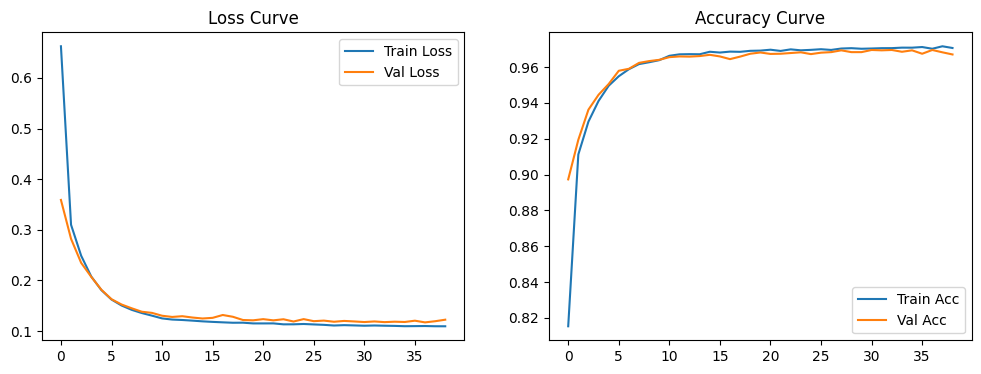

In [3]:
conv_configs = [   
    {
        'layer_type': 'conv',
        'in_channels': 1,
        'out_channels': 8,  # 减少通道数
        'kernel_size': 3,   # 更小的卷积核
        'stride': 1,
        'padding': 1,       # 依然保持尺寸
        'weight_decay': True,
        'weight_decay_lambda': 1e-4
    },
    {
        'layer_type': 'pool',
        'pooling_type': 'average',
        'kernel_size': 2,
        'stride': 2
    },
    {
        'layer_type': 'conv',
        'in_channels': 8,
        'out_channels': 16,  # 第二层也减小
        'kernel_size': 3,
        'stride': 1,
        'padding': 1,
        'weight_decay': True,
        'weight_decay_lambda': 1e-4
    },
    {
        'layer_type': 'pool',
        'pooling_type': 'average',
        'kernel_size': 2,
        'stride': 2
    }
]
fc_configs = [
    {"in_dim": 784, "out_dim": 10, "weight_decay": True, "weight_decay_lambda": 1e-4},
]



trainer_0 = train_model(conv_configs, fc_configs, 'ReLU', False, 0.1, 100, f'./saved_models/Q5/cnn_model1', early_stop=7) 
         

best accuracy performence has been updated: 0.00000 --> 0.88810
Epoch 1/100:
[Train] loss: 0.57657, score: 0.83062
[Dev] loss: 0.35801, score: 0.88810
best accuracy performence has been updated: 0.88810 --> 0.93720
Epoch 2/100:
[Train] loss: 0.23926, score: 0.92841
[Dev] loss: 0.21367, score: 0.93720
best accuracy performence has been updated: 0.93720 --> 0.95300
Epoch 3/100:
[Train] loss: 0.18231, score: 0.94689
[Dev] loss: 0.16317, score: 0.95300
best accuracy performence has been updated: 0.95300 --> 0.95910
Epoch 4/100:
[Train] loss: 0.14844, score: 0.95660
[Dev] loss: 0.14449, score: 0.95910
best accuracy performence has been updated: 0.95910 --> 0.96380
Epoch 5/100:
[Train] loss: 0.13008, score: 0.96214
[Dev] loss: 0.12625, score: 0.96380
best accuracy performence has been updated: 0.96380 --> 0.96590
Epoch 6/100:
[Train] loss: 0.12003, score: 0.96579
[Dev] loss: 0.12795, score: 0.96590
best accuracy performence has been updated: 0.96590 --> 0.96910
Epoch 7/100:
[Train] loss: 0.1

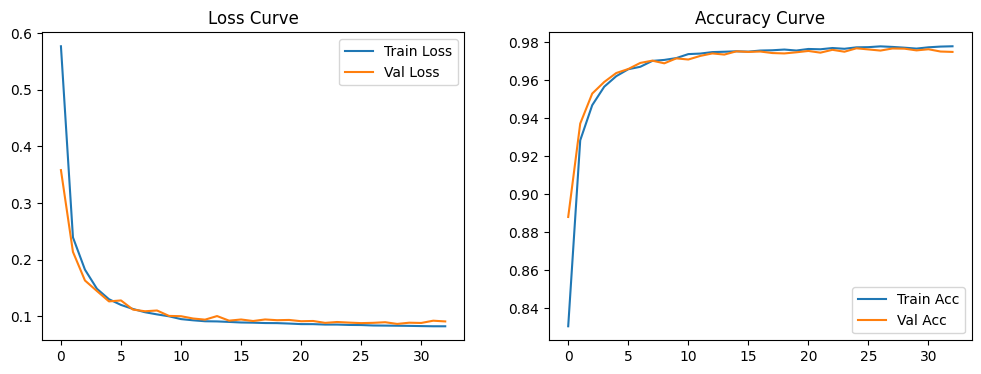

In [4]:
conv_configs = [   
    {
        'layer_type': 'conv',
        'in_channels': 1,
        'out_channels': 8,     # 减小通道数
        'kernel_size': 3,
        'stride': 1,
        'padding': 1,
        'weight_decay': True,
        'weight_decay_lambda': 1e-4
    },
    {
        'layer_type': 'pool',
        'pooling_type': 'max',   # 从 average 改为 max
        'kernel_size': 2,
        'stride': 2
    },
    {
        'layer_type': 'conv',
        'in_channels': 8,
        'out_channels': 16,
        'kernel_size': 3,
        'stride': 1,
        'padding': 1,
        'weight_decay': True,
        'weight_decay_lambda': 1e-4
    },
    {
        'layer_type': 'pool',
        'pooling_type': 'max',   # 从 average 改为 max
        'kernel_size': 2,
        'stride': 2
    }
]

fc_configs = [
    {"in_dim": 784, "out_dim": 10, "weight_decay": True, "weight_decay_lambda": 1e-4},
]


trainer_1 = train_model(conv_configs, fc_configs, 'ReLU', False, 0.1, 100, f'./saved_models/Q5/cnn_model2', early_stop=7) 

